# Alpha geodesics on the space of Univariate Normal Distributions

> Objective: vizualise the geodesics induced by the alpha connections on the space of univariate normal distributions, and compare with the Fisher geodesic. 

In [1]:
import matplotlib.pyplot as plt

import geomstats.backend as gs
import geomstats.visualization as visualization
from geomstats.information_geometry.normal import (
    UnivariateNormalAlpha,
    UnivariateNormalDistributions,
)

## Visualisation

For some exemples of alphas (-1,-0.5,0,0.5,1)

/home/luisfpereira/Repos/github/geomstats/geomstats/information_geometry/normal.py:958: RuntimeWarning: overflow encountered in power
  christoffels[..., 0, 1, 0] = -(1 + alpha) / (sigma**3)
/home/luisfpereira/Repos/github/geomstats/geomstats/information_geometry/normal.py:959: RuntimeWarning: overflow encountered in power
  christoffels[..., 1, 0, 0] = -(1 + alpha) / (sigma**3)
/home/luisfpereira/Repos/github/geomstats/geomstats/information_geometry/normal.py:963: RuntimeWarning: overflow encountered in power
  christoffels[..., 0, 0, 1] = (1 - alpha) / (sigma**3)
/home/luisfpereira/Repos/github/geomstats/geomstats/information_geometry/normal.py:965: RuntimeWarning: overflow encountered in power
  christoffels[..., 1, 1, 1] = -2 * (1 + 2 * alpha) / (sigma**3)


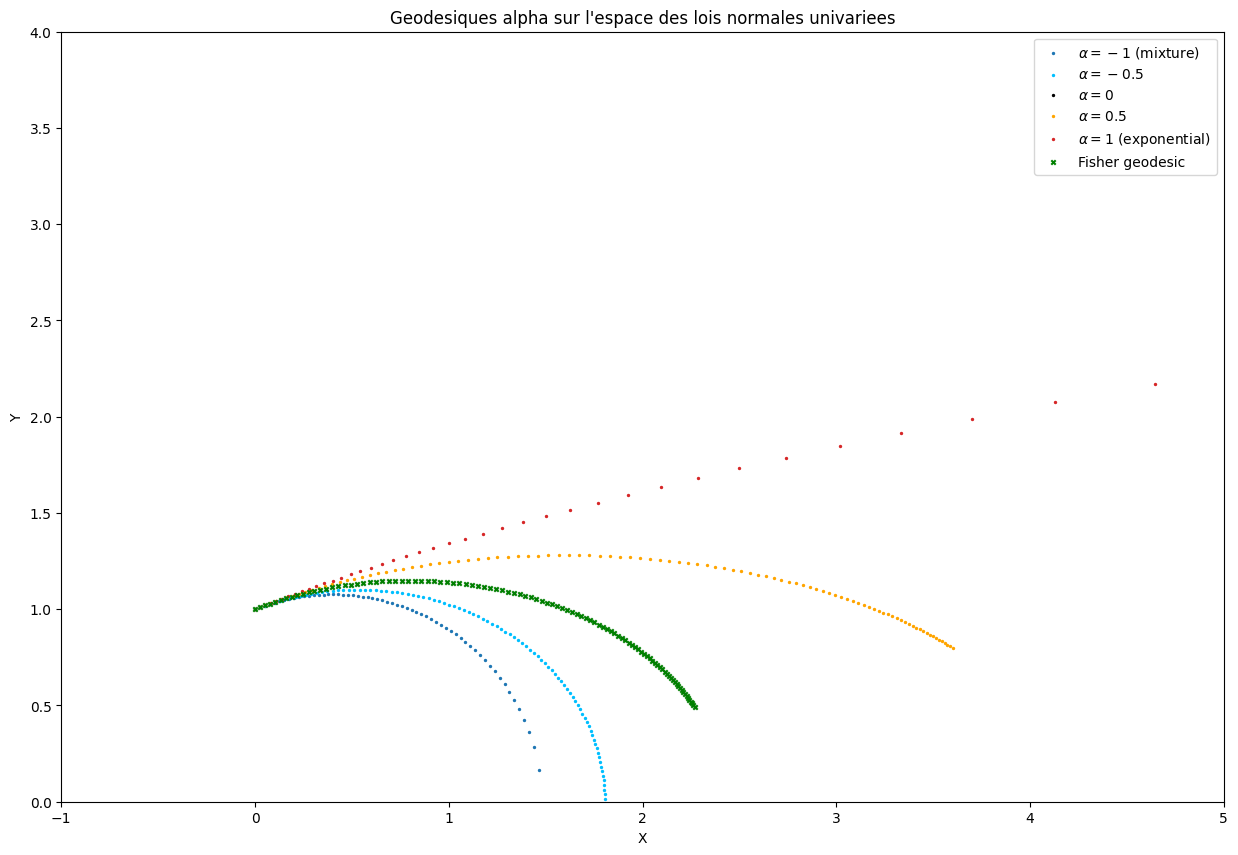

In [2]:
riemannian_manifold = UnivariateNormalDistributions(equip=True)
space = UnivariateNormalDistributions(equip=False)


start_point = gs.array([0.0, 1.0])
initial_tangent_vec = gs.array([0.5, 0.2])
end_time = 5.0


alphas = [-1.0, -0.5, 0.0, 0.5, 1.0]
colors = ["tab:blue", "deepskyblue", "black", "orange", "tab:red"]
labels = [
    r"$\alpha=-1$ (mixture)",
    r"$\alpha=-0.5$",
    r"$\alpha=0$",
    r"$\alpha=0.5$",
    r"$\alpha=1$ (exponential)",
]

fig, ax = plt.subplots(figsize=(15, 10))
ax.set_xlim(-1, 5)
ax.set_ylim(0, 4)


times = gs.linspace(0.0, end_time, 100)

for alpha, color, label in zip(alphas, colors, labels):
    space.equip_with_connection(
        UnivariateNormalAlpha, riemannian_manifold=riemannian_manifold, alpha=alpha
    )
    points = space.connection.geodesic(
        initial_point=start_point,
        initial_tangent_vec=initial_tangent_vec,
    )(times)
    points = points[points[:, 1] > 1e-6]

    visualization.plot(
        points,
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker=".",
        color=color,
        s=8,
        label=label,
    )


points = riemannian_manifold.metric.geodesic(
    initial_point=start_point,
    initial_tangent_vec=initial_tangent_vec,
)(times)
points = points[points[:, 1] > 1e-6]

visualization.plot(
    points,
    ax=ax,
    space="H2_poincare_half_plane",
    coords_type="half-space",
    marker="x",
    color="green",
    s=10,
    label="Fisher geodesic",
)

ax.legend(loc="best")
ax.set_title("Geodesiques alpha sur l'espace des lois normales univariees")
plt.show()